## Time Series Modeling

In [1]:
import statsmodels

statsmodels.__version__

# Compare the version with official website
# https://www.statsmodels.org/stable/index.html

'0.14.2'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (20, 5)
matplotlib.rcParams['figure.dpi'] = 200
matplotlib.rcParams["hist.bins"] = 40

In [3]:
temperature_tunis = pd.read_csv('https://drive.google.com/u/1/uc?id=1xL0Dz65LOIY-2KMZz6vgJZVTlRmvOj7Z&export=download', index_col=0).iloc[:,0]
temperature_tunis.index = pd.to_datetime(temperature_tunis.index)
temperature_tunis = temperature_tunis.resample("1d").mean().interpolate()

<Axes: >

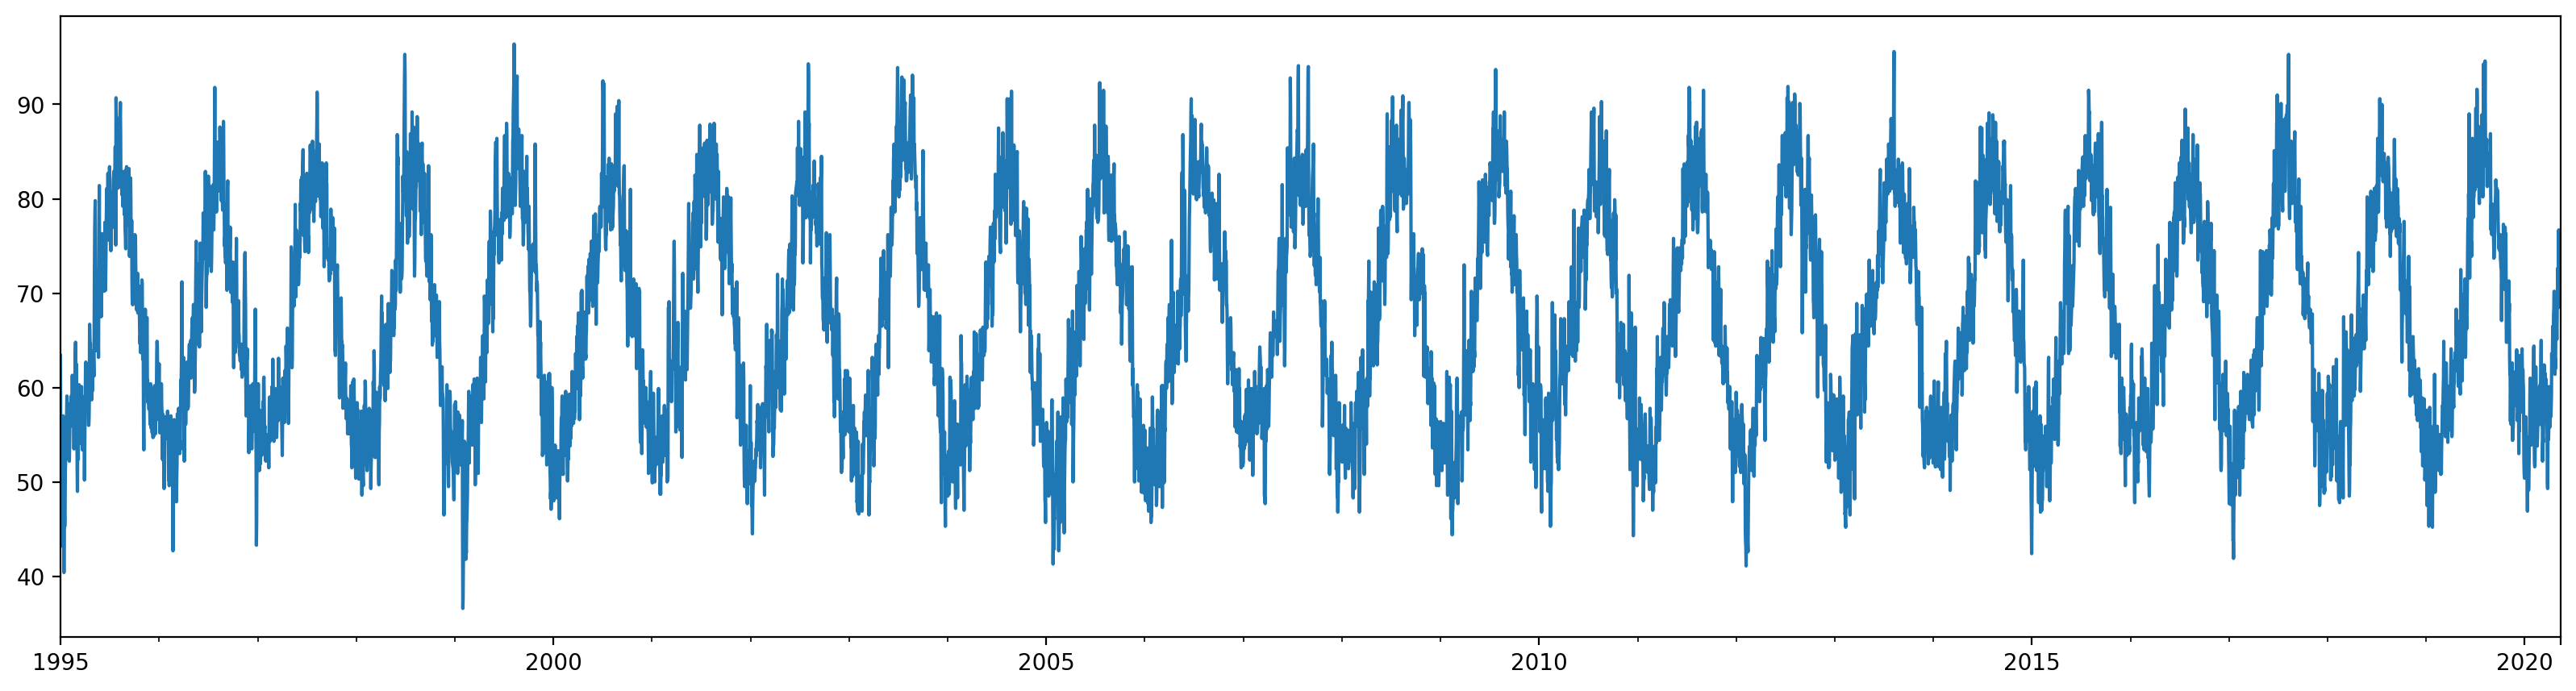

In [4]:
temperature_tunis.plot()

Models in statsmodel:

https://www.statsmodels.org/stable/tsa.html

## 1. Autoregressive (AR) Model

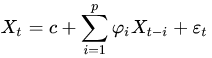

AR Model assumes we can calculate the next value using the previous `p` data points.

Example:

```
ts = [12, 24, 45, 32, 34]
```

Running an AR model with `p=2` is equivalent to running a linear regression with
```
X = [
    [12, 24],
    [24, 45],
    [45, 32],
]

y = [
    45,
    32,
    34
]
```

Usage:

`from statsmodels.tsa.ar_model import AutoReg`

The model provides us with convenient functions:

- `.predict()`, `.plot_predict()` for forecasting
- `.aic`, `.bic` etc. for checking the correctness of the model with information criteria

Task:

Try to fit the temperature TS with an AR model.

In [ ]:
# Your code here

from statsmodels.tsa.ar_model import AutoReg

test_days = 200

res = AutoReg(temperature_tunis[:-test_days], lags = 180).fit()

res.summary()

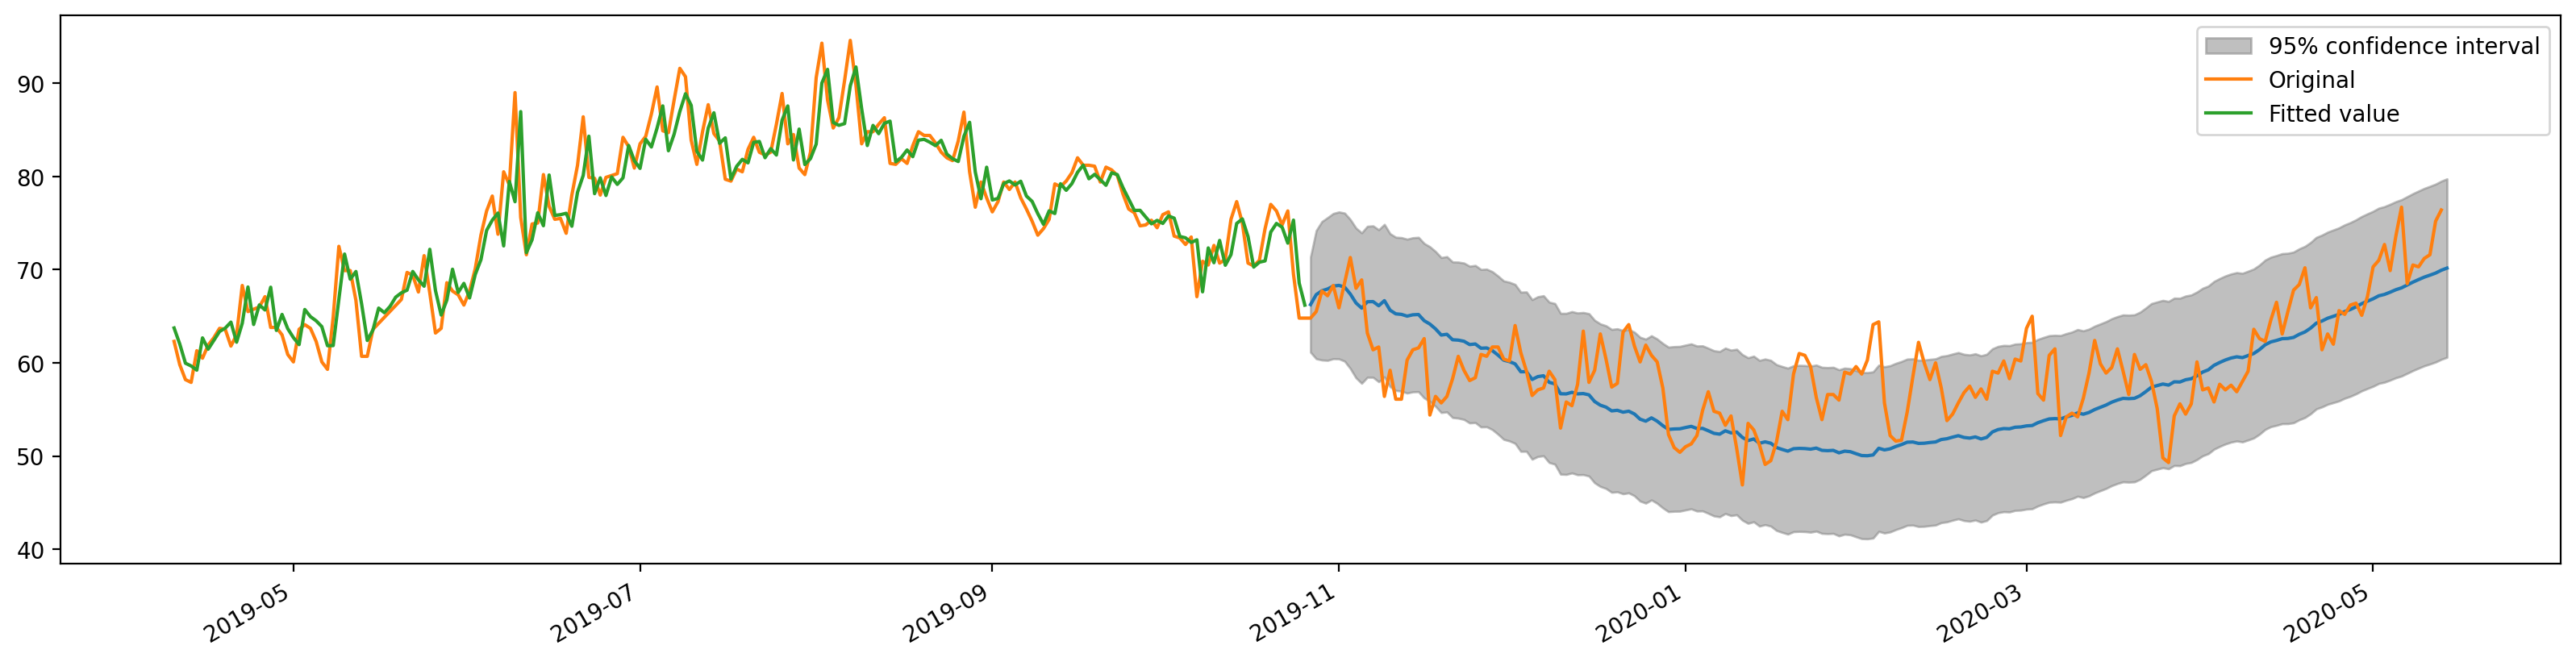

In [8]:
fig = res.plot_predict(start=len(temperature_tunis) - test_days, end=len(temperature_tunis) )
ax = fig.axes[0]

original_values = temperature_tunis[-test_days * 2:]
original_values.name = "Original"
original_values.plot(ax=ax)

fitted_values = res.fittedvalues[-test_days:]
fitted_values.name = "Fitted value"

fitted_values.plot(ax=ax)

plt.legend()


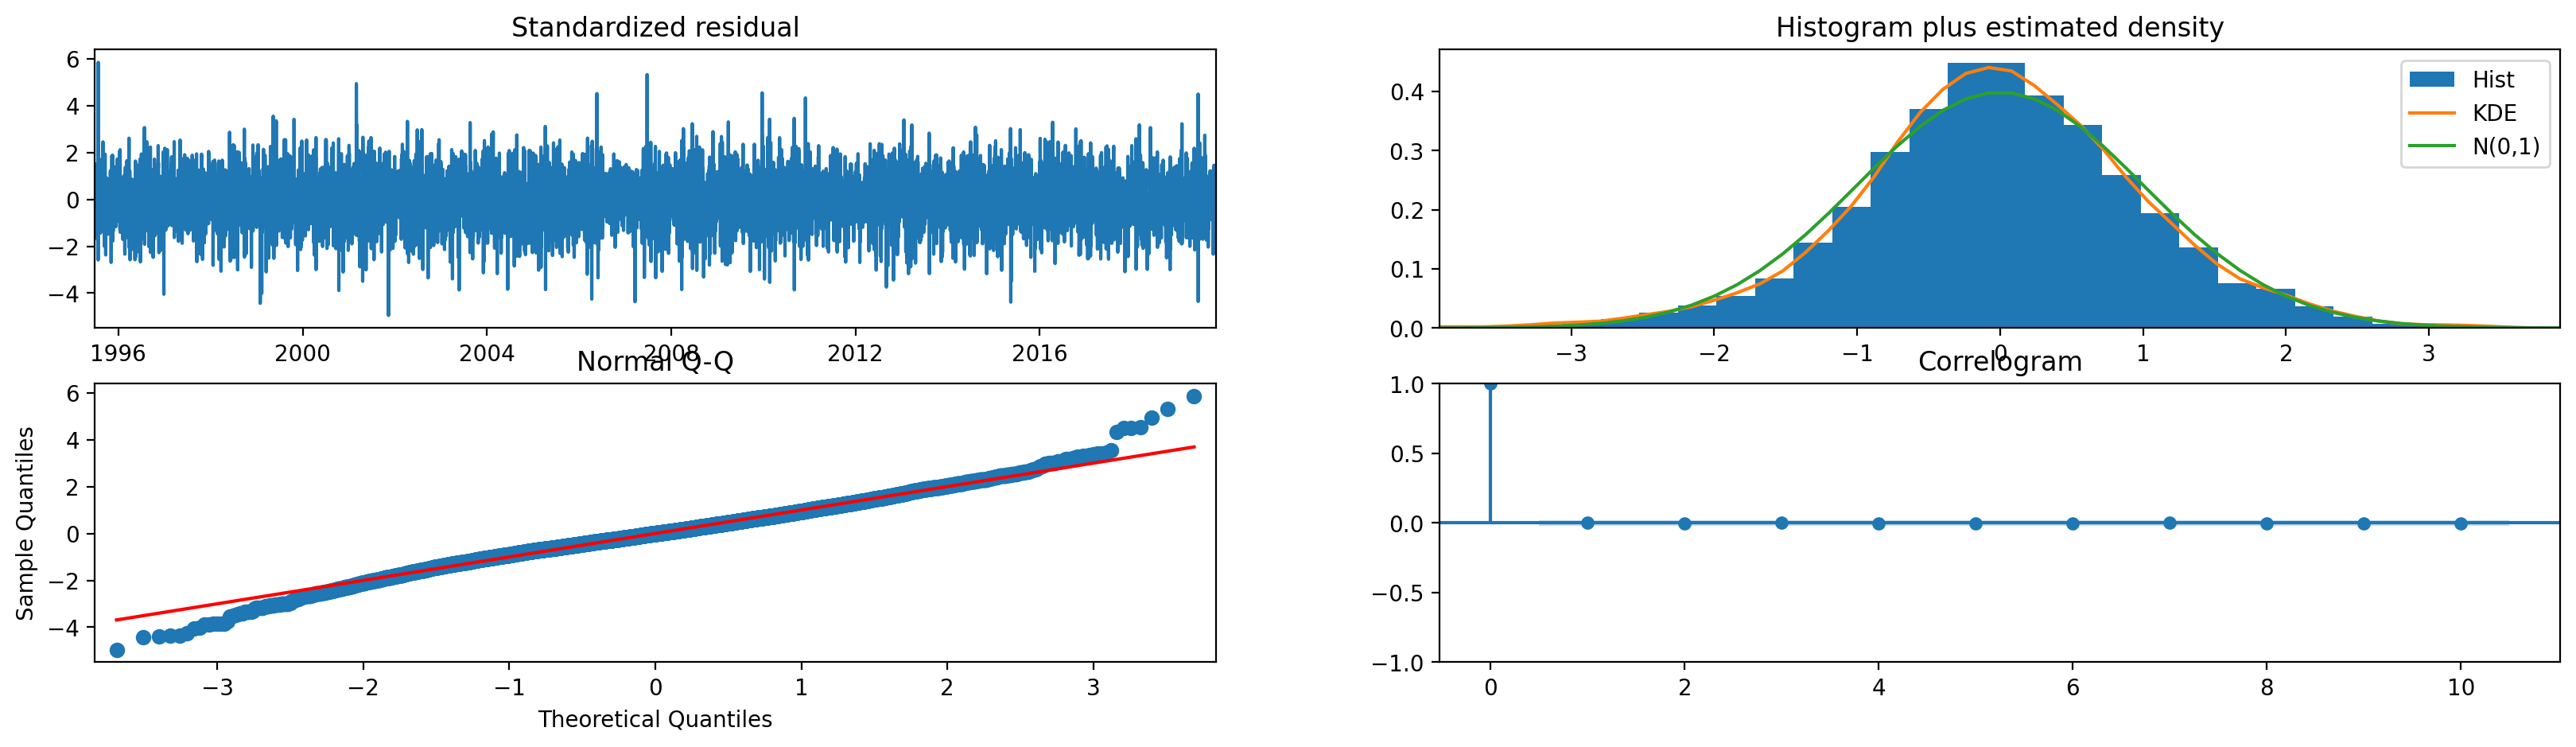

In [ ]:
res.plot_diagnostics()
pass

## 2. MA Model
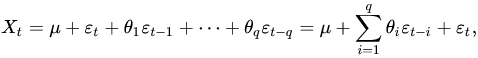

A moving-average model is a linear regression of the current value of the series against current and previous (observed) white noise error terms.

MA Model assumes the timeseries is 0 mean.

## 3. ARMA Model
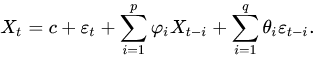

ARMA model is the combination of AR and MA model.

## 4. ARIMA Model

What sets ARMA and ARIMA apart is differencing. An ARMA model is a stationary model; If your model isn’t stationary, then you can achieve stationarity by taking a series of differences. The “I” in the ARIMA model stands for integrated; It is a measure of how many non-seasonal differences are needed to achieve stationarity. If no differencing is involved in the model, then it becomes simply an ARMA.

> The (p,d,q) order of the model for the autoregressive, differences, and moving average components. d is always an integer, while p and q may either be integers or lists of integers.


In [11]:
from statsmodels.tsa.arima.model import ARIMA

res = ARIMA(temperature_tunis[:-test_days], order=(20,0,1)).fit()

res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:         AvgTemperature   No. Observations:                 9065
Model:                ARIMA(20, 0, 1)   Log Likelihood              -21900.478
Date:                Sat, 20 Apr 2024   AIC                          43846.956
Time:                        09:14:42   BIC                          44010.536
Sample:                    01-01-1995   HQIC                         43902.598
                         - 10-26-2019                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         67.2403      2.139     31.441      0.000      63.049      71.432
ar.L1          0.4947     51.521      0.010      0.992    -100.485     101.474
ar.L2          0.1843     49.145      0.004      0.997     -96.138      96.507
ar.L3          0.0022     13.070      0.000      1.000     -25.615      25.620
ar.L4          0.0620      6.113      0.010      0.992     -11.919      12.043
ar.L5          0.0355      0.390      0.091      0.928      -0.729       0.800
ar.L6          0.0304      1.649      0.018      0.985      -3.202       3.263
ar.L7          0.0251      0.810      0.031      0.975      -1.563       1.613
ar.L8          0.0322      0.923      0.035      0.972      -1.777       1.841
ar.L9          0.0122      1.237      0.010      0.992      -2.413       2.437
ar.L10         0.0282      0.062      0.454      0.650      -0.094       0.150
ar.L11         0.0106      1.425      0.007      0.994      -2.783       2.804
ar.L12         0.0304      0.110      0.277      0.782      -0.184       0.245
ar.L13         0.0075      1.615      0.005      0.996      -3.158       3.173
ar.L14         0.0081      0.356      0.023      0.982      -0.690       0.706
ar.L15         0.0008      0.583      0.001      0.999      -1.142       1.143
ar.L16         0.0164      0.227      0.072      0.943      -0.429       0.462
ar.L17         0.0055      0.948      0.006      0.995      -1.852       1.863
ar.L18         0.0020      0.151      0.013      0.989      -0.294       0.298
ar.L19        -0.0052      0.176     -0.029      0.977      -0.351       0.340
ar.L20        -0.0029      0.342     -0.008      0.993      -0.674       0.668
ma.L1          0.4591     51.521      0.009      0.993    -100.520     101.439
sigma2         7.3422      0.088     83.266      0.000       7.169       7.515
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):               541.09
Prob(Q):                              0.96   Prob(JB):                         0.00
Heteroskedasticity (H):               0.94   Skew:                            -0.10
Prob(H) (two-sided):                  0.12   Kurtosis:                         4.18
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

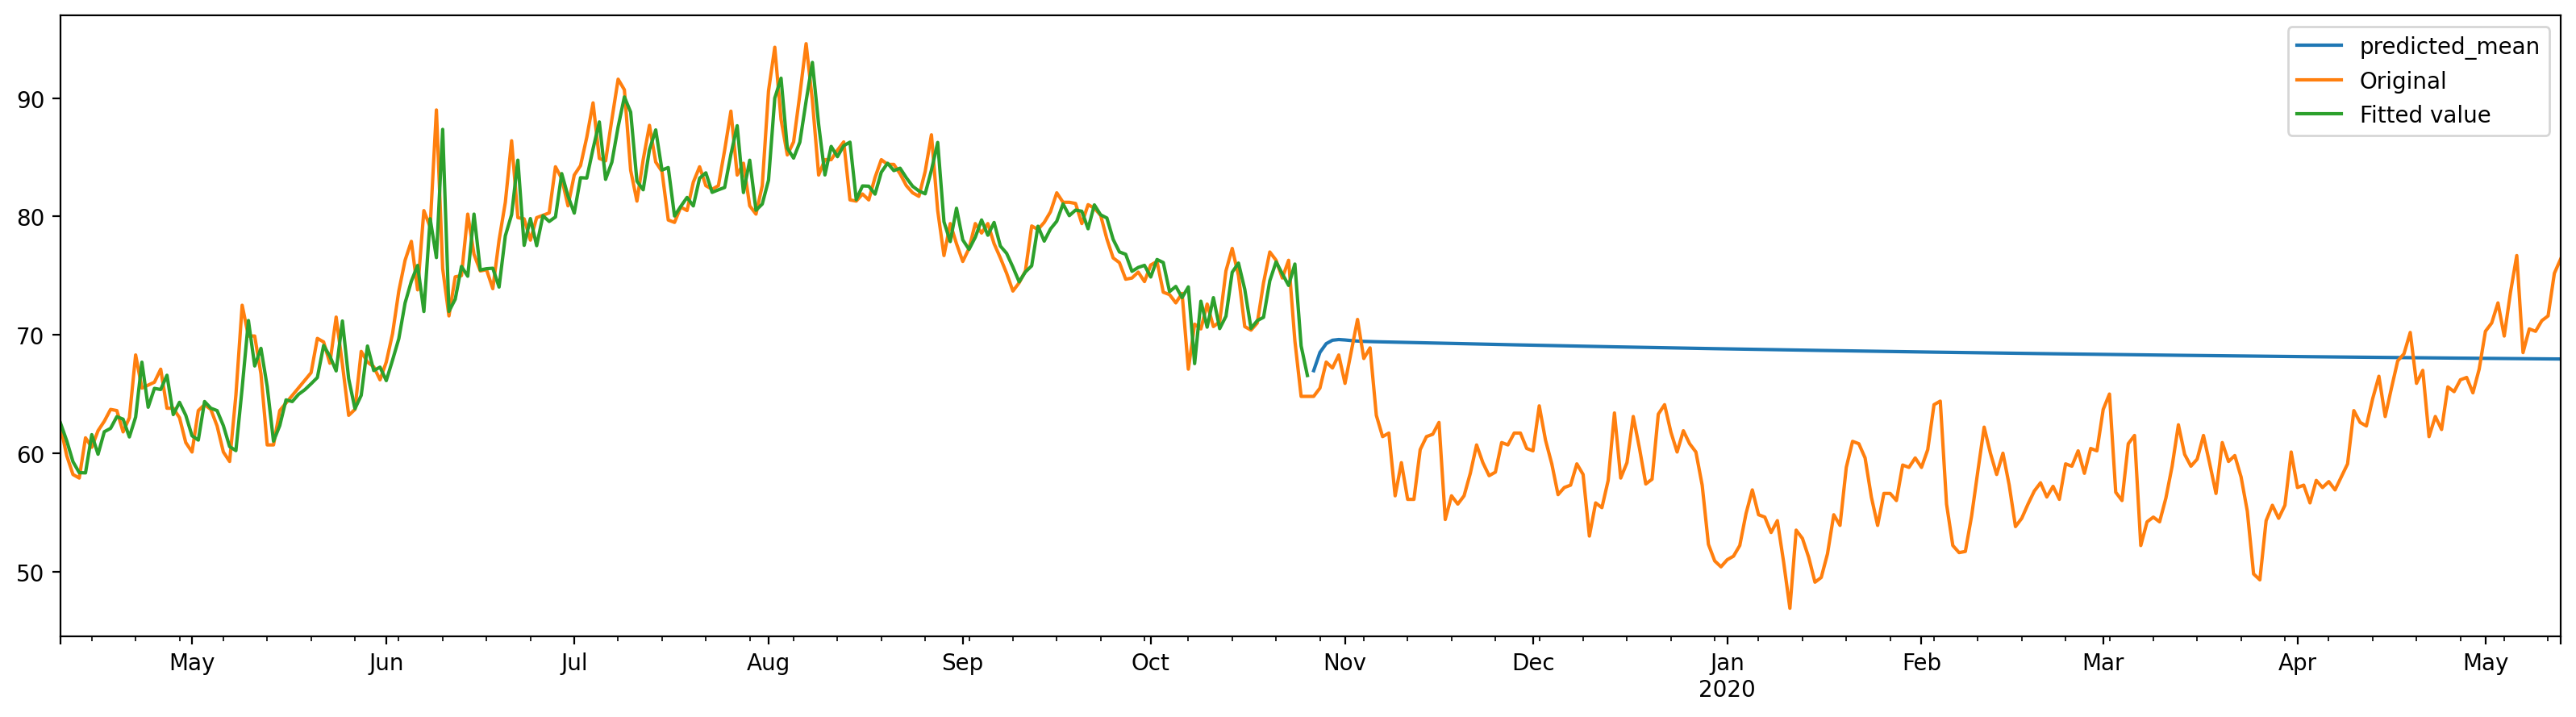

In [ ]:
ax = res.forecast(test_days).plot()

original_values = temperature_tunis[-test_days * 2:]
original_values.name = "Original"
original_values.plot(ax=ax)

fitted_values = res.fittedvalues[-test_days:]
fitted_values.name = "Fitted value"
# fitted_values.index = range(len(temperature_tunis) - test_days * 2, len(temperature_tunis) - test_days)

fitted_values.plot(ax=ax)

plt.legend()


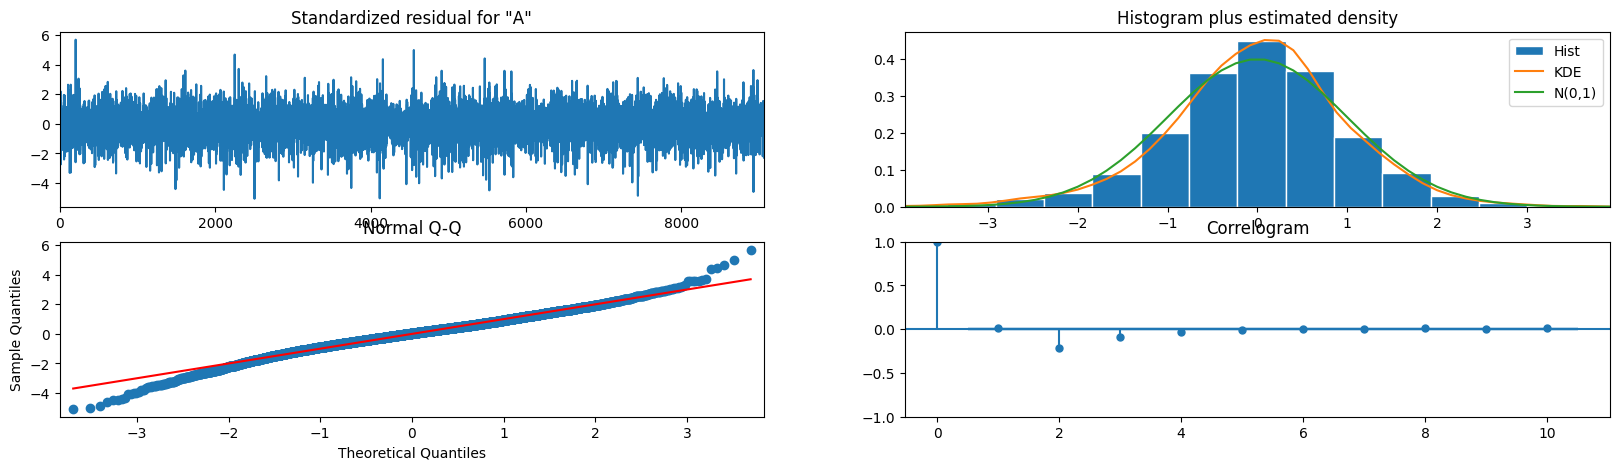

In [ ]:
res.plot_diagnostics()
pass

## 5. SARIMA



SARIMA is a model combined ARIMA with seasonal effect.

Usage:

`SARIMAX(data, order=(p,d,q), seasonal_order=(P,D,Q,s))`

Note that the "Seasonal" in SARIMAX model instruct the model to run regression with another set of time points.

For example,

- ARIMA(2,0,0) takes day-1 and day-2 as the regression input.
- SARIMA(0,0,0)(2,0,0,4) takes day-4 and day-8 as the regression input.




In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import time

In [ ]:
t1 = time.time()

res = SARIMAX(temperature_tunis[:-test_days], order=(2,0,0), seasonal_order=(2,0,0,50)).fit()

print(f"Time spent: {time.time() - t1:.2f}s")

res.summary()

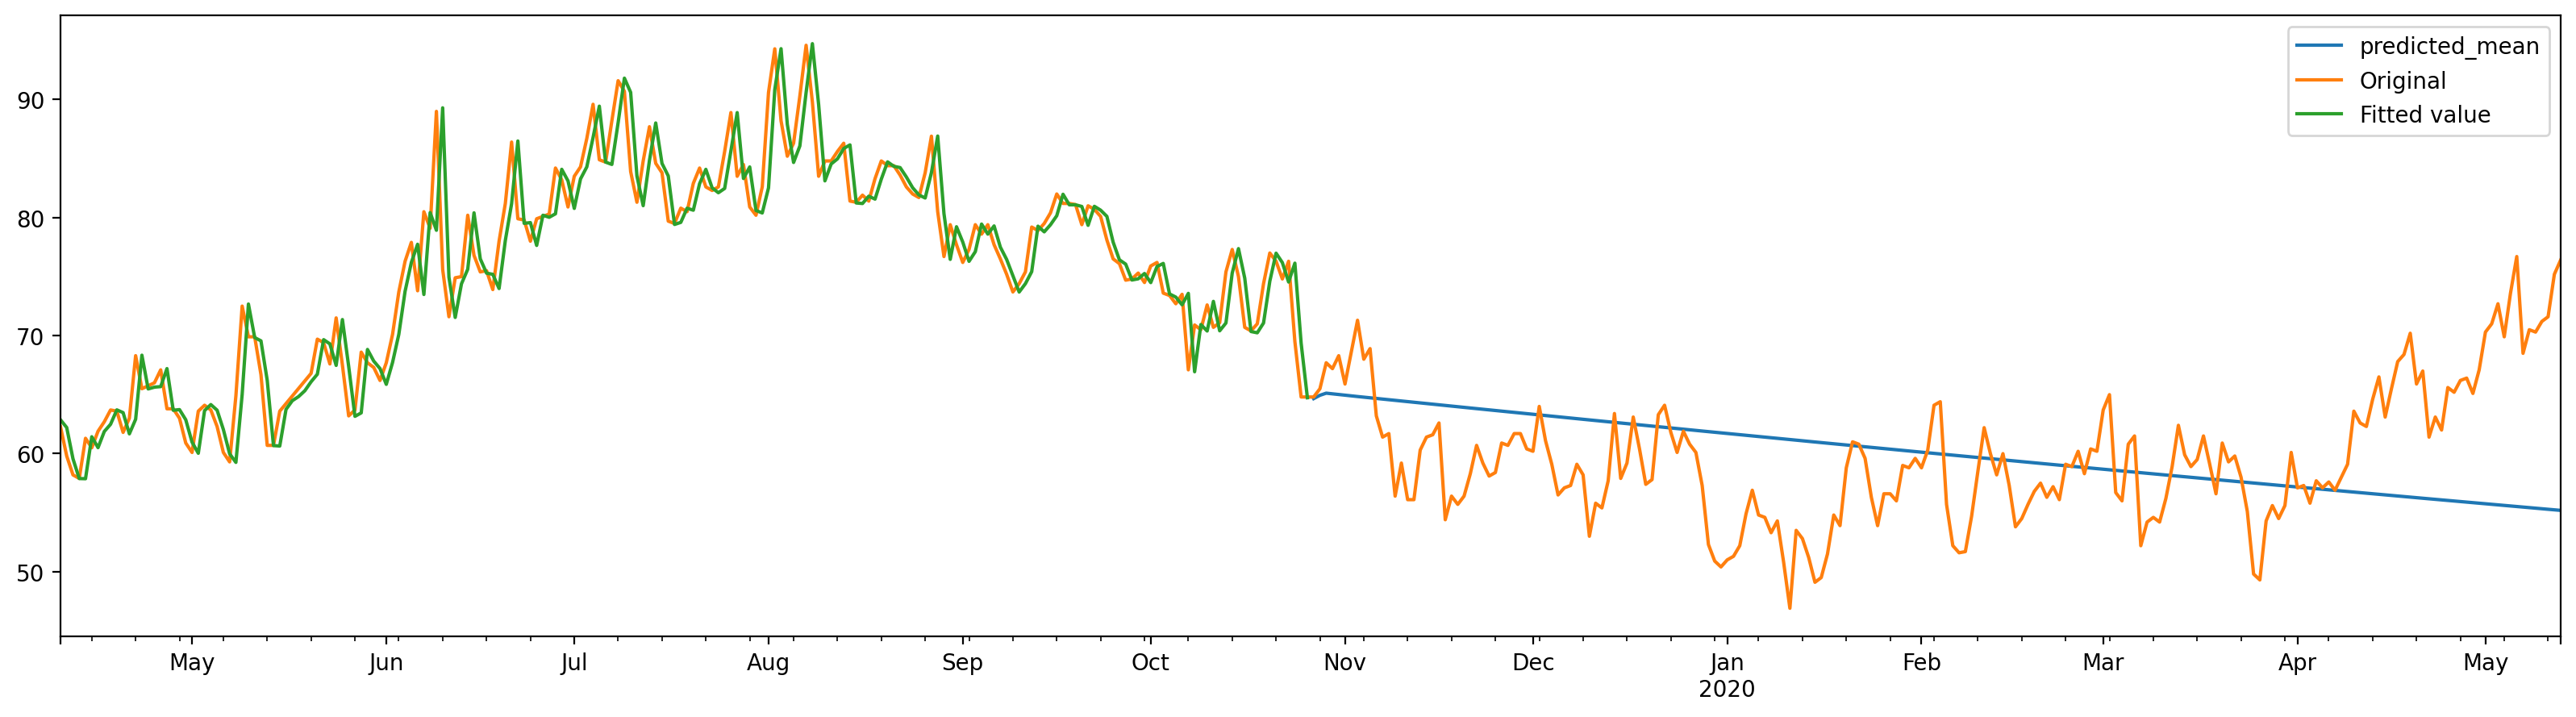

In [ ]:
ax = res.forecast(test_days).plot()

original_values = temperature_tunis[-test_days * 2:]
original_values.name = "Original"
original_values.plot(ax=ax)

fitted_values = res.fittedvalues[-test_days:]
fitted_values.name = "Fitted value"

fitted_values.plot(ax=ax)

plt.legend()


## 6. Modeling seasonality

### 6.1 seasonal_decompose (`from statsmodels.tsa.seasonal import seasonal_decompose`)

If we can identify some seasonality effect.

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

### Your code here
result = seasonal_decompose(temperature_tunis, period=365)

<Axes: >

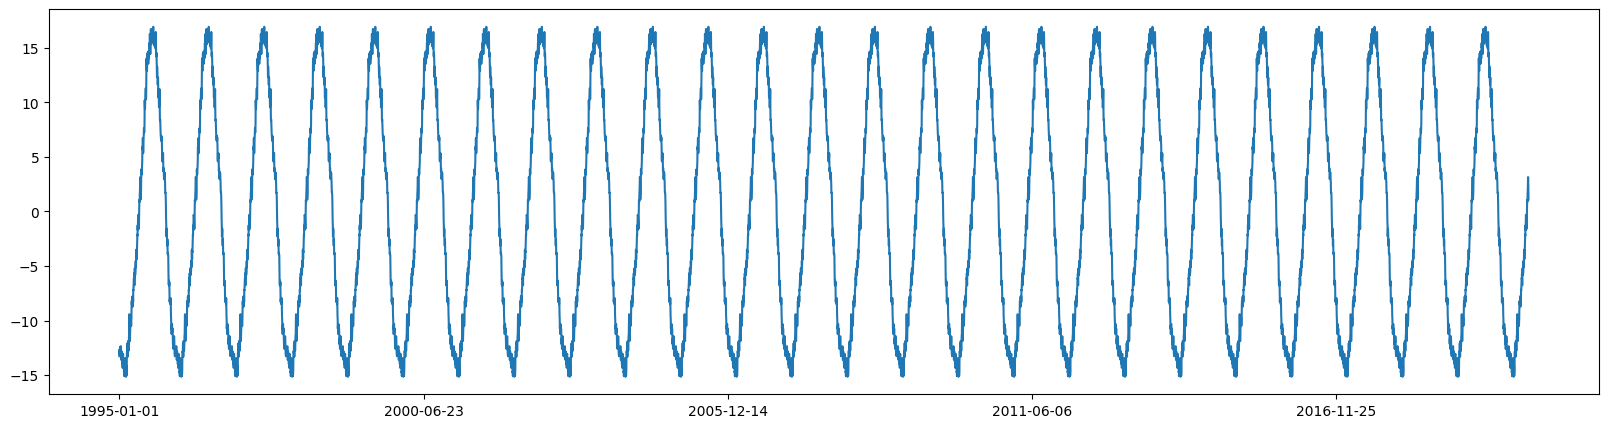

In [ ]:
result.seasonal.plot()

<Axes: >

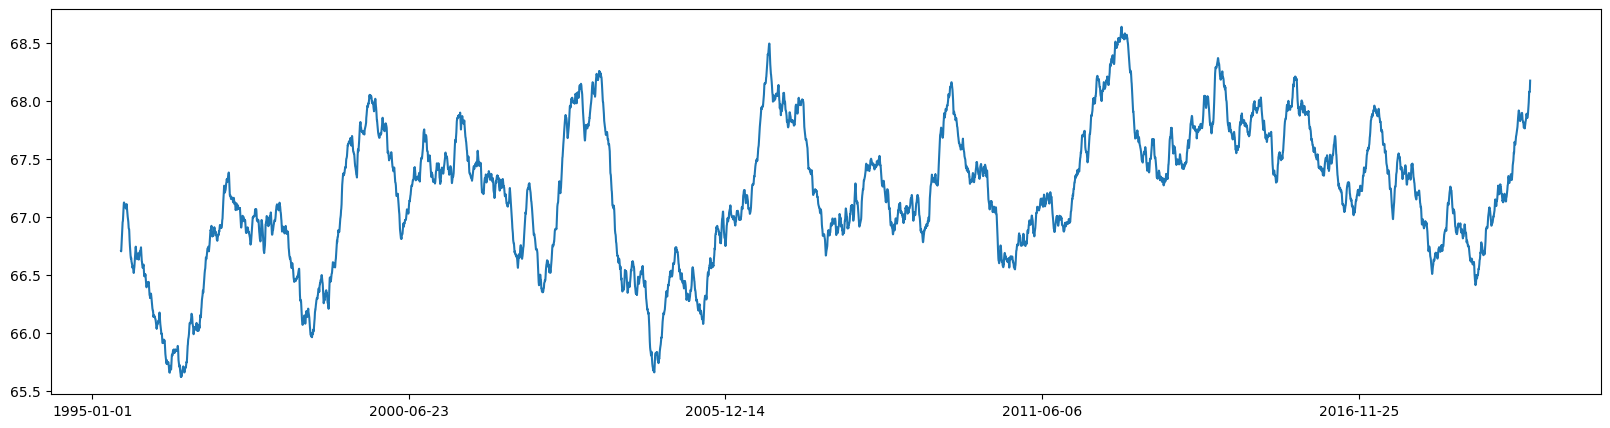

In [ ]:
result.trend.plot()

<Axes: >

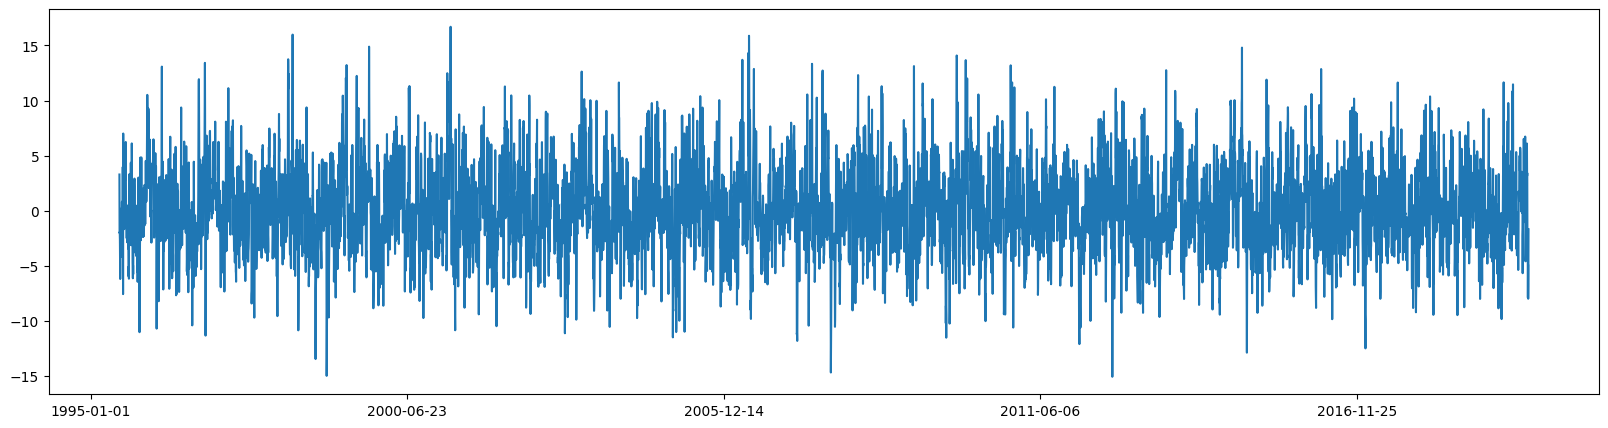

In [ ]:
result.resid.plot()

### 6.2 One hot seasonality

https://www.statsmodels.org/dev/generated/statsmodels.tsa.deterministic.Seasonality.html



Imagine we have identified a 7 days seasonality pattern, we may include one hot features like:

|Date of week|One hot features|
|-|-|
|Sunday|[1, 0, 0, 0 ,0 ,0 ,0]|
|Monday|[0, 1, 0, 0 ,0 ,0 ,0]|
|Tuesday|[0, 0, 1, 0 ,0 ,0 ,0]|
|Wednesday|[0, 0, 0, 1 ,0 ,0 ,0]|
|Thursday|[0, 0, 0, 0 ,1 ,0 ,0]|
|Friday|[0, 0, 0, 0 ,0 ,1 ,0]|
|Saturday|[0, 0, 0, 0 ,0 ,0 ,1]|

### 6.3 Fourier

https://www.statsmodels.org/dev/generated/statsmodels.tsa.deterministic.Fourier.html

For longer seasonality, it is unrealistic to create one hot features for each of the time point.  Instead, we try to model the shape of seasonality effect with multiple waves.

**Example**

The following demonstrate how waves can be added together to form different shapes.  Try to modify the parameters in the add equation and observe the change in the output shape.

In [13]:
waves

,s1,c1,s2,c2
0,0.000000e+00,1.000000,0.000000e+00,1.000000
1,6.989026e-03,0.999976,1.397771e-02,0.999902
2,1.397771e-02,0.999902,2.795269e-02,0.999609
3,2.096571e-02,0.999780,4.192221e-02,0.999121
4,2.795269e-02,0.999609,5.588353e-02,0.998437
...,...,...,...,...
895,-2.795269e-02,0.999609,-5.588353e-02,0.998437
896,-2.096571e-02,0.999780,-4.192221e-02,0.999121
897,-1.397771e-02,0.999902,-2.795269e-02,0.999609
898,-6.989026e-03,0.999976,-1.397771e-02,0.999902


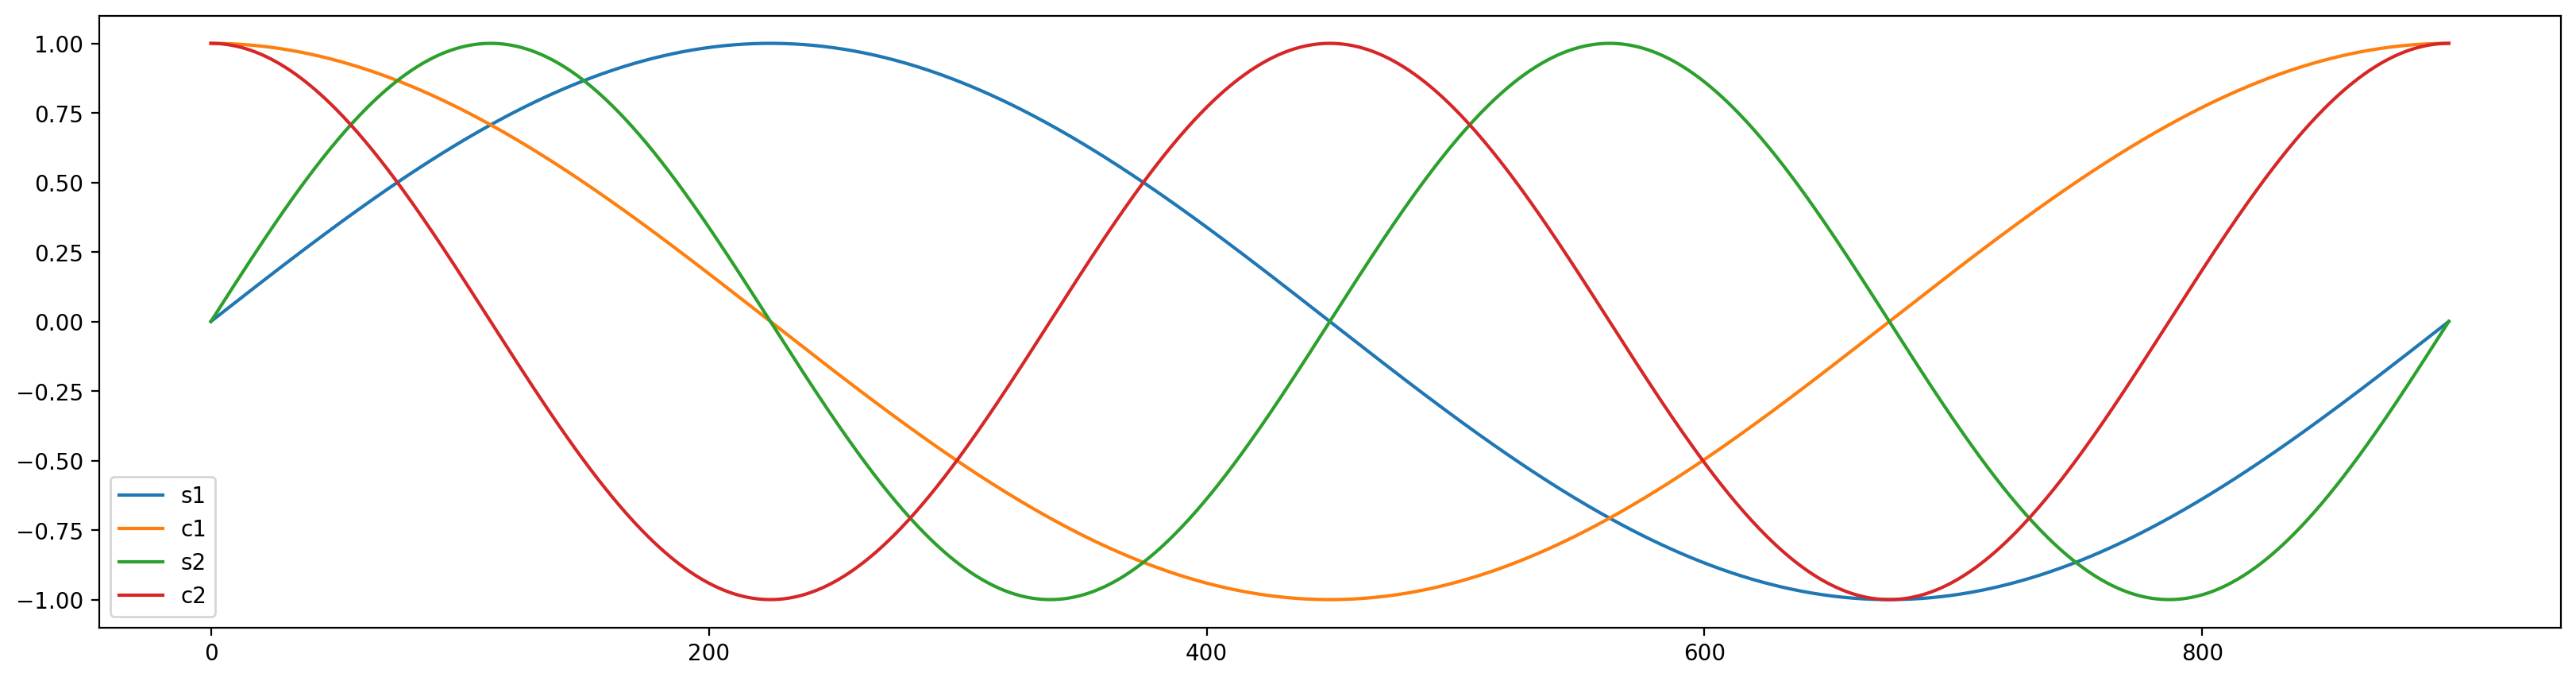

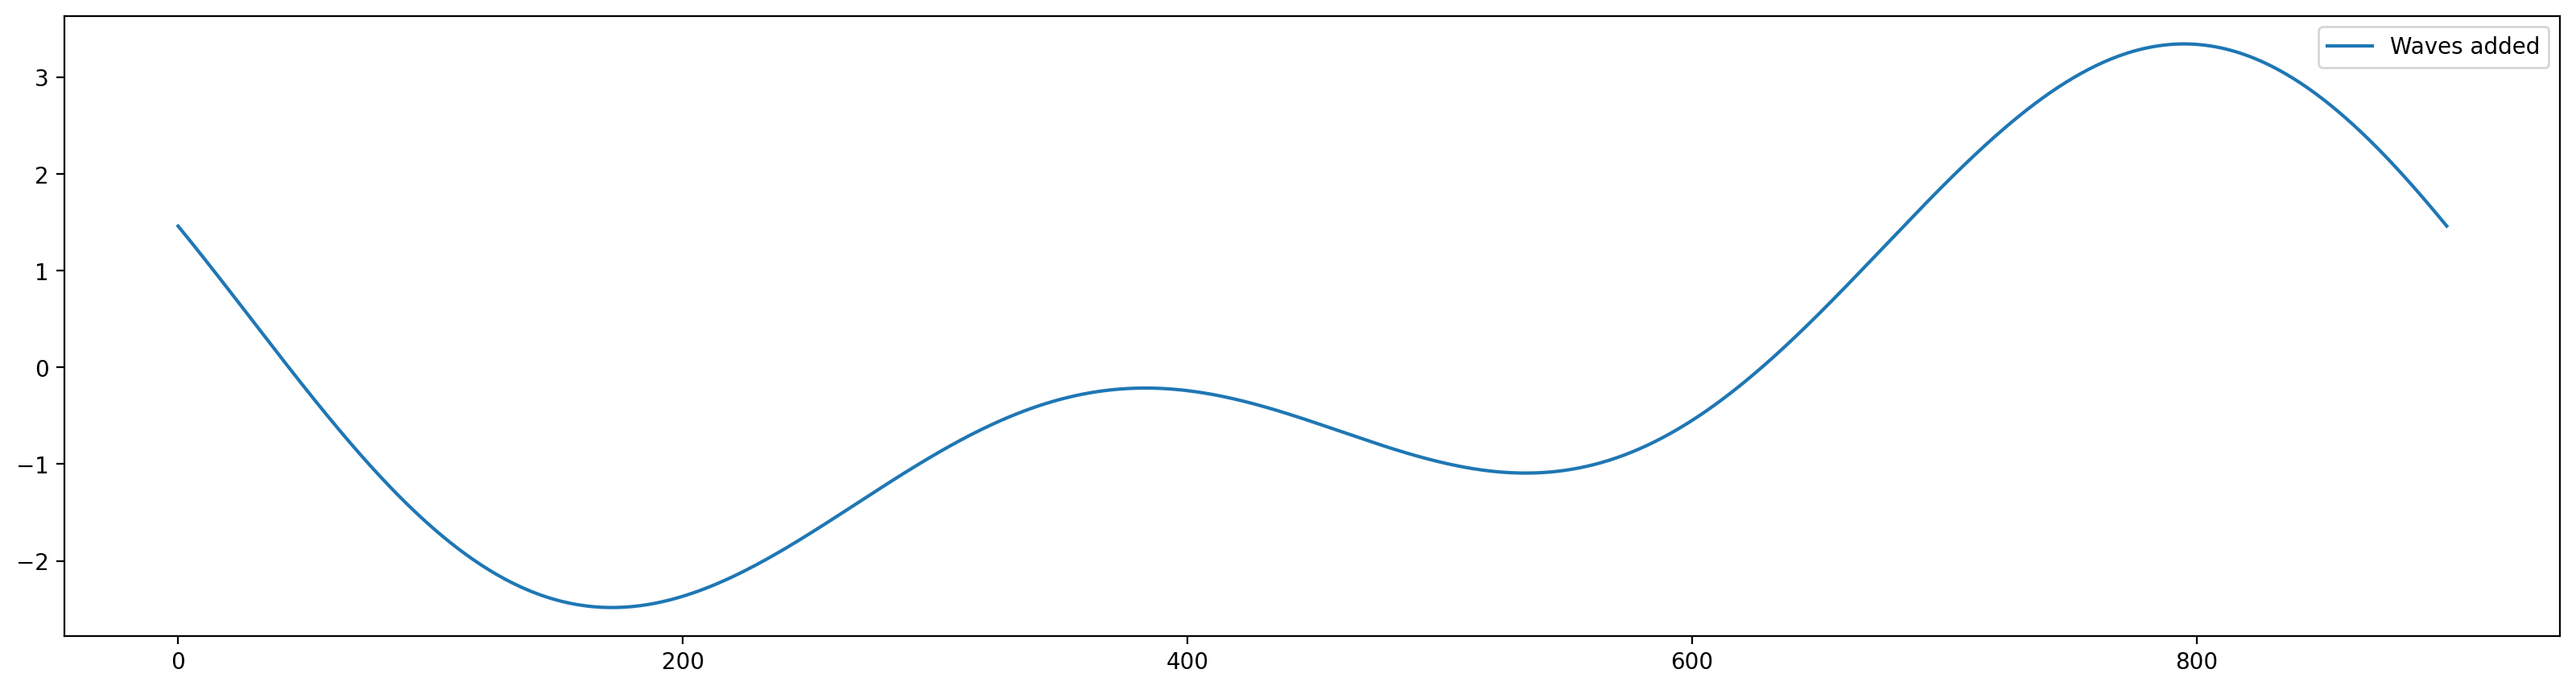

In [12]:
x = np.linspace(0, 2 * np.pi, 900)

waves = pd.DataFrame({
    "s1": np.sin(x),
    "c1": np.cos(x),
    "s2": np.sin(x*2),
    "c2": np.cos(x*2),
})

waves.plot()

plt.figure()
added = -1.65 * waves['s1']  + 1.012 * waves['c1'] -1.45 * waves['s2'] + 0.45 * waves['c2'] # Change parameters here.
added.name = "Waves added"
added.plot()
plt.legend()

In [14]:
waves

,s1,c1,s2,c2
0,0.000000e+00,1.000000,0.000000e+00,1.000000
1,6.989026e-03,0.999976,1.397771e-02,0.999902
2,1.397771e-02,0.999902,2.795269e-02,0.999609
3,2.096571e-02,0.999780,4.192221e-02,0.999121
4,2.795269e-02,0.999609,5.588353e-02,0.998437
...,...,...,...,...
895,-2.795269e-02,0.999609,-5.588353e-02,0.998437
896,-2.096571e-02,0.999780,-4.192221e-02,0.999121
897,-1.397771e-02,0.999902,-2.795269e-02,0.999609
898,-6.989026e-03,0.999976,-1.397771e-02,0.999902


In [15]:
added

0      1.462000
1      1.430132
2      1.398131
3      1.366001
4      1.333748
         ...   
895    1.588054
896    1.556763
897    1.525320
898    1.493731
899    1.462000
Name: Waves added, Length: 900, dtype: float64

In [16]:
from sklearn.linear_model import LinearRegression

In [17]:
model = LinearRegression()

model.fit(waves, added)

LinearRegression()

In [18]:
model.coef_

array([-1.65 ,  1.012, -1.45 ,  0.45 ])

## 7. Prophet from facebook

https://facebook.github.io/prophet/docs/quick_start.html

In [19]:
from prophet import Prophet

In [20]:
train = temperature_tunis.reset_index().rename(columns={"index": "ds", "AvgTemperature": "y"})

model = Prophet()
# model.add_regressor('')  # Allow you to add more regresssor
model.fit(train[-2000:-360])

# Predict on valid set
y_pred = model.predict(train[-360:])

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpo40gq4qp/0m5ooktm.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpo40gq4qp/xytw1jz_.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=61904', 'data', 'file=/tmp/tmpo40gq4qp/0m5ooktm.json', 'init=/tmp/tmpo40gq4qp/xytw1jz_.json', 'output', 'file=/tmp/tmpo40gq4qp/prophet_modelo3he_0wh/prophet_model-20240420102128.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
10:21:28 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
10:21:28 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


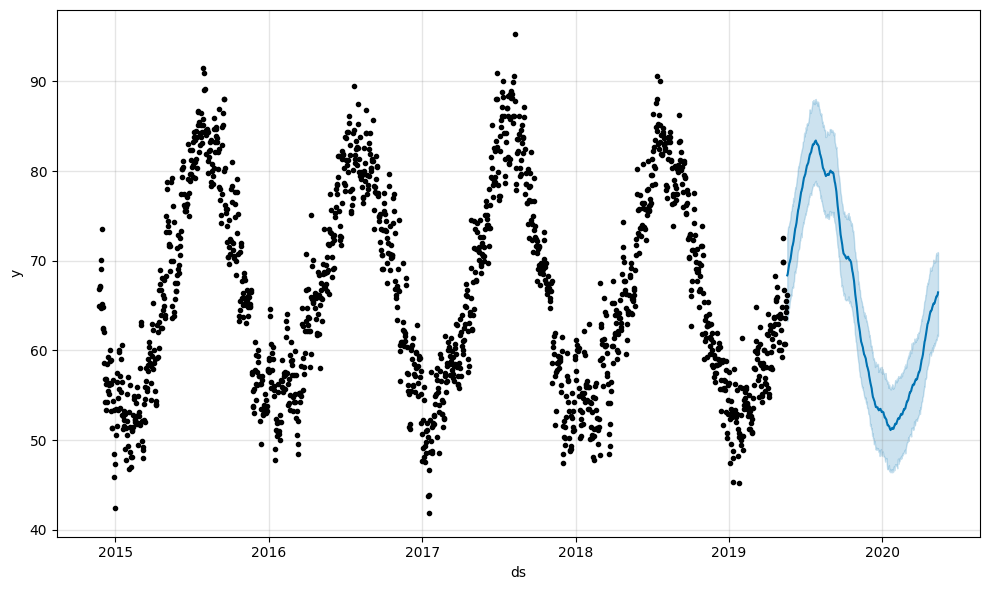

In [ ]:
model.plot(y_pred)
pass